Load Era5 hourly data, pressure data for calculating wind shear

In [2]:
import sys
import xarray as xr
import matplotlib.pyplot as plt


sys.path.append("..")

from src.data.load_era5 import load_era5

ds = load_era5("../data/raw/era5_sample")
ds_pressure = load_era5("../data/raw/era5_pressure_sample.nc")

# Wrong coords downloaded, subset
ds_pressure_subset = ds_pressure.sel(
    latitude=slice(60, 48),
    longitude=ds_pressure.longitude[(ds_pressure.longitude >= 350) | (ds_pressure.longitude <= 2)]
)

# Convert longitude from 0-360 to -180/180
ds_pressure_subset = ds_pressure_subset.assign_coords(
    longitude=(((ds_pressure_subset.longitude + 180) % 360) - 180)
)
ds_pressure_subset = ds_pressure_subset.sortby("longitude")

#Merge pressure subset and regular hourly era5
ds_merged = xr.merge([ds, ds_pressure_subset])
print(ds_merged)

<xarray.Dataset> Size: 1MB
Dimensions:         (valid_time: 12, latitude: 49, longitude: 49,
                     pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 96B 2020-01-01 ... 2020-01-03...
    expver          (valid_time) <U4 192B '0001' '0001' '0001' ... '0001' '0001'
  * latitude        (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude       (longitude) float64 392B -10.0 -9.75 -9.5 ... 1.5 1.75 2.0
  * pressure_level  (pressure_level) float64 16B 850.0 500.0
    number          int64 8B 0
Data variables:
    u10             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    v10             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    d2m             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    t2m             (valid_time, latitude, longitude) float32 115

/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitl

Calcuate bulk wind shear

<xarray.DataArray (valid_time: 12, latitude: 49, longitude: 49)> Size: 115kB
array([[[11.810921 , 11.783103 , 11.732591 , ..., 12.271763 ,
         11.987693 , 11.584295 ],
        [11.045081 , 11.094142 , 11.171443 , ..., 11.819808 ,
         11.427158 , 10.924804 ],
        [10.399547 , 10.528849 , 10.685073 , ..., 11.041808 ,
         10.770505 , 10.359329 ],
        ...,
        [ 1.9222908,  1.6822766,  1.51565  , ...,  7.531998 ,
          8.443672 ,  9.150482 ],
        [ 2.185054 ,  1.8218828,  1.5239352, ...,  6.860432 ,
          7.5532374,  8.367338 ],
        [ 2.5450969,  2.2297382,  1.9141111, ...,  6.3087378,
          6.930074 ,  7.5935225]],

       [[14.309933 , 13.801257 , 13.404883 , ..., 15.747887 ,
         15.811749 , 15.745253 ],
        [13.128012 , 12.756929 , 12.55234  , ..., 14.909716 ,
         14.852724 , 14.678766 ],
        [12.049618 , 11.873054 , 11.889504 , ..., 13.487811 ,
         13.441128 , 13.2798195],
...
        [ 1.553804 ,  1.5057474,  1.4865

Text(0.5, 1.0, 'Shear 850hPa - 500hPa')

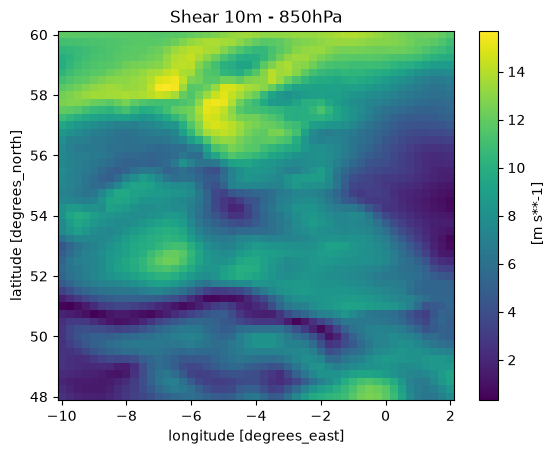

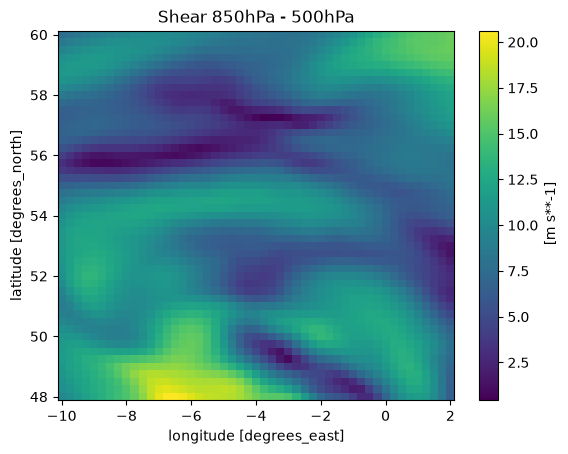

In [3]:
from src.features.meteorology import wind_shear

# 10m to 850hPa shear
shear_10m_850 = wind_shear(
    ds_merged['u10'], ds_merged['v10'],
    ds_merged['u'].sel(pressure_level=850), ds_merged['v'].sel(pressure_level=850)
)

# 850hPa to 500hPa shear (deep layer shear)
shear_850_500 = wind_shear(
    ds_merged['u'].sel(pressure_level=850), ds_merged['v'].sel(pressure_level=850),
    ds_merged['u'].sel(pressure_level=500), ds_merged['v'].sel(pressure_level=500)
)

#SPEED SHEAR

shear_10m_850_computed = shear_10m_850.compute()
print(shear_10m_850_computed)
fig1, ax1 = plt.subplots()
shear_10m_850_computed.isel(valid_time=0).plot(ax=ax1)
ax1.set_title("Shear 10m - 850hPa")

print(shear_850_500)
fig2, ax2 = plt.subplots()
shear_850_500.isel(valid_time=0).plot(ax=ax2)
ax2.set_title("Shear 850hPa - 500hPa")

<xarray.DataArray (valid_time: 12, latitude: 49, longitude: 49)> Size: 115kB
array([[[-1.40234375e+01, -1.53806763e+01, -1.65280457e+01, ...,
         -2.95277863e+01, -3.03542786e+01, -3.07351990e+01],
        [-1.56688385e+01, -1.71182251e+01, -1.82349548e+01, ...,
         -2.66292114e+01, -2.71400757e+01, -2.77358093e+01],
        [-1.73373108e+01, -1.87247467e+01, -1.98496246e+01, ...,
         -2.27879639e+01, -2.32672424e+01, -2.41593323e+01],
        ...,
        [-1.14981079e+01, -1.19088287e+01, -1.12885590e+01, ...,
          3.54239655e+01,  2.34510498e+01, -3.11861572e+01],
        [-8.06025696e+00, -7.10887146e+00, -5.68247986e+00, ...,
          2.73668518e+01,  1.48553467e+01, -2.23856812e+01],
        [-6.21524048e+00, -4.53669739e+00, -3.06092834e+00, ...,
         -7.74810791e-01, -1.25146484e+01, -1.01711578e+01]],

       [[-2.69793854e+01, -2.73370209e+01, -2.75722046e+01, ...,
         -4.38269958e+01, -4.52871552e+01, -4.63164673e+01],
        [-2.75403137e+01, 

Text(0.5, 1.0, 'Directional Shear 850hPa - 500hPa')

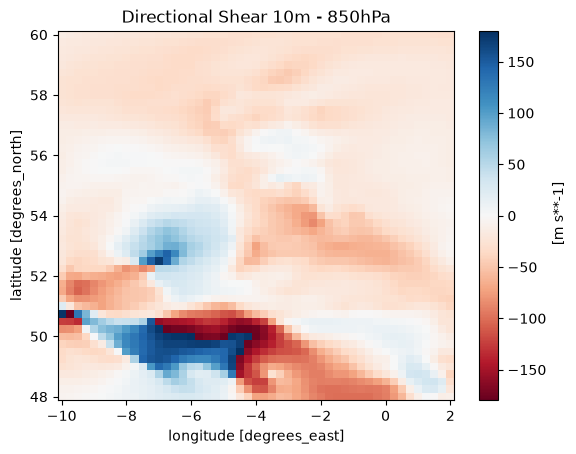

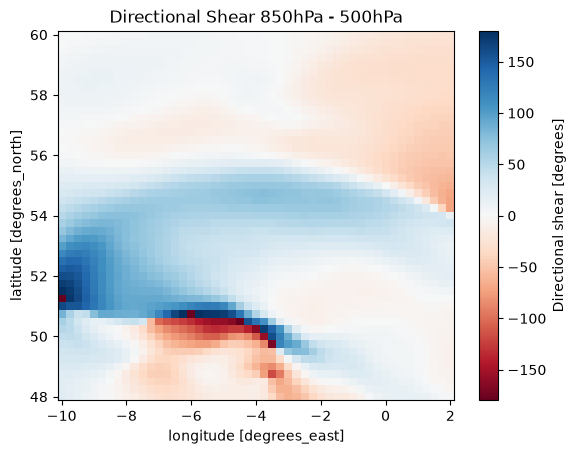

In [4]:
from src.features.meteorology import directional_shear

# 10m to 850hPa shear
shear_10m_850 = directional_shear(
    ds_merged['u10'], ds_merged['v10'],
    ds_merged['u'].sel(pressure_level=850), ds_merged['v'].sel(pressure_level=850)
)

# 850hPa to 500hPa shear (deep layer shear)
shear_850_500 = directional_shear(
    ds_merged['u'].sel(pressure_level=850), ds_merged['v'].sel(pressure_level=850),
    ds_merged['u'].sel(pressure_level=500), ds_merged['v'].sel(pressure_level=500)
)

#DIRECTIONAL SHEAR

shear_10m_850_computed = shear_10m_850.compute()
print(shear_10m_850_computed)
fig1, ax1 = plt.subplots()
shear_10m_850_computed.isel(valid_time=0).plot(ax=ax1, cmap="RdBu", vmin=-180, vmax=180)
ax1.set_title("Directional Shear 10m - 850hPa")

shear_850_500_computed = shear_850_500.compute()
fig2, ax2 = plt.subplots()
plot = shear_850_500_computed.isel(valid_time=0).plot(ax=ax2, cmap="RdBu", vmin=-180, vmax=180, add_colorbar=False)
cbar = fig2.colorbar(plot, ax=ax2)
cbar.set_label("Directional shear [degrees]")
ax2.set_title("Directional Shear 850hPa - 500hPa")

/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitl

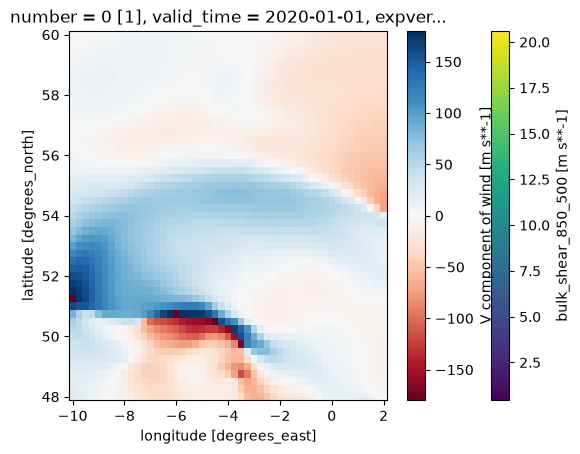

In [ ]:
import sys
import xarray as xr
import matplotlib.pyplot as plt
sys.path.append("..")

from src.data.load_era5 import load_era5, convert_longitude, subset_area
from src.features.meteorology import compute_shear_features

# Load
ds_single = load_era5("../data/raw/era5_sample")
ds_pressure = load_era5("../data/raw/era5_pressure_sample.nc")

# Clean up pressure data (global grid -> your area, longitude convention)
ds_pressure = convert_longitude(ds_pressure)
ds_pressure = subset_area(ds_pressure, north=60, south=48, west=-10, east=2)

# Merge
ds_merged = xr.merge([ds_single, ds_pressure])

# Compute all shear features in one call
shear_features = compute_shear_features(ds_merged)

shear_features['bulk_shear_850_500'].isel(valid_time=0).plot()
shear_features['dir_shear_850_500'].isel(valid_time=0).plot(cmap="RdBu", vmin=-180, vmax=180)